In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
# initialize the codespace with only A-stabilizer 

def lattice_space(H, L):
    lattice = np.zeros((H, L))
    for i in range(H):
        for j in range(L):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice
import random

def energy(lattice):
    
    H = lattice.shape[0]
    L = lattice.shape[1]
    energy = 0
    for i in range(H):
        for j in range(L):
            # Periodic boundary conditions
            right = lattice[(i+1)% H, (j+1) % L]
            down  = lattice[(i+1) % H, j]
            energy +=  (lattice[i, j] + right + down)% 2
    return energy

def compute_dE(lattice, i, j):
    # Sum over four neighbors with periodic boundaries
    H = lattice.shape[0]
    L = lattice.shape[1]
    s = lattice[i, j]
    ds = (s+1)%2
    left = lattice[i, (j-1)%L] + lattice [(i-1)%H, (j-1)%L]
    right = lattice[(i-1)%H, j] + lattice[i, (j+1)%L]
    bottom = lattice[(i+1)%H, j] + lattice[(i+1)%H, (j+1)%L]
    E  = (left+s)%2 + (right+s)%2 + (bottom+s)%2
    E_new = (left+ds)%2 + (right+ds)%2 + (bottom+ds)%2
    dE = E_new - E
    if dE == 0:
        raise ValueError("No change in energy")
    return dE



In [3]:
def monte_carlo_error(lattice, num_steps, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    for _ in range(num_steps):
        i = random.randint(0, H - 1)
        j = random.randint(0, L - 1)
        r = random.random()
        if r < error_rate:
            # Flip the qubit
            lattice[i, j] = (lattice[i, j] + 1) % 2
            """
        for i in range(H):
            for j in range(L):
                r = random.random()
                if r < error_rate:
                    # Flip the qubit
                    lattice[i, j] = (lattice[i, j] + 1) % 2
            """

    return lattice
    
def nonzero_random():
    r = random.random()
    while r == 0.0:
        r = random.random()
    return r

def bkl(lattice, steps, energy_hist, error_rate, time_list):
    f = 1e-8
    beta = math.log((3+error_rate)/error_rate)/3
    H = lattice.shape[0]
    L = lattice.shape[1]
    for step in range(steps):
        # for i_ in range(H):
        #     for j_ in range(L):
        #         r = random.random()
        #         if r < error_rate:
        #             # Flip the qubit
        #             lattice[i_, j_] = (lattice[i_, j_] + 1) % 2

        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                dE = compute_dE(lattice, i, j)
                if dE not in classes:
                    classes[dE] = []
                classes[dE].append((i, j))
        # print(classes)
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        rates = {}
        total_rate = 0.0
        for dE in sorted(classes):
            rate = len(classes[dE])* (dE / (np.exp(beta * dE)-1 ) )#- error_rate)
            rates[dE] = rate
            total_rate += rate
        if total_rate == 0:
            print(len(classes), "total_rate is 0")
            continue
        # rate_list = []
        # rate_list.append(total_rate)
        # Choose a class according to the rates (weighted selection)
        r = random.uniform(0, total_rate)
        cumulative = 0.0
        chosen_class = None
        for dE, rate in rates.items():
            cumulative += rate
            if r <= cumulative :
                # print("hi")
                chosen_class = dE
                break
        if total_rate == 0.0:
            raise ValueError("Total rate is zero, cannot choose a class.")
            
        # From the chosen class, select a spin uniformly at random
        i, j = random.choice(classes[chosen_class])
        # Flip the spin
        lattice[i, j] = (lattice[i, j] + 1) % 2
        energy_hist.append(energy(lattice))   
        rho3 = nonzero_random()
        step = -1/total_rate * np.log(rho3)
        # print(rho3, total_rate)
        
        time_list.append(step)
    return lattice

In [4]:
# optimal decoder
import numpy as np

def syndrome_detector(lattice):
    """
    Detects errors in syndrom measuring A-stabilizer
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = []
    #errors = np.zeros((H,L))
    for i in range(H):
        for j in range(L):
            if (lattice[i, j]+lattice[i, (j+1)%L]+lattice[(i+1)%H, (j+1)%L]) % 2 != 0:  # error by A-stablizer
                #errors[i][j]= 1
                errors.append((i,j))   
    return errors

def error_qubit_detector(lattice):
    """
    Detects errors in the lattice and returns a list of qubits to be flipped.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = syndrome_detector(lattice)
    error_qubits = np.zeros((H,L),dtype=int)
    for i in range(H):
        for j in range(L):
            if not (errors[i][j] or errors[(i-1)%H][j] or errors[(i-1)%H][(j-1)%L]):  
                error_qubits[i][j]= 1   # Assuming 1 indicates an error
    return error_qubits

def sweeper(lattice):
    """
    Sweeps through the lattice and move the defects. to the first row.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L))
    latt = lattice.copy()
    for i in range(H-1):      # to H or H-1?/
        for j in range(L):
            if (latt[(H-i-1)%H, j]+latt[(H-i)%H, j]+latt[(H-i)%H, (j+1)%L]) % 2 == 1:  # error by A-stablizer
                errors[(H-i-1)%H][j]= 1
                latt[(H-i-1)% H][j] = (latt[(H-i-1) % H][j] + 1) % 2 
    return latt, errors

def update_rule(lattice):
    """
    Update rule 102, input row_i+1, returns row_i
    """
    # H = lattice.shape[0]
    L = lattice.shape[1]
    f = np.eye(L,dtype=int)
    f += cyclic_shift(L)  # cyclic shift matrix
    # for j in range(L):
    #     for i in range(L):
    #         if j % 3 ==0 and i % 3 == 0:
    #             f[j][i] = 1
    #         if j % 3 == 0 and i % 3 == 1:
    #             f[j][i] = 1
    #         if j % 3 == 1 and i % 3 == 1:
    #             f[j][i] = 1
    #         if j % 3 == 1 and i % 3 == 2:
    #             f[j][i] = 1
    #         if j % 3 == 2 and i % 3 == 0:
    #             f[j][i] = 1
    #         if j % 3 == 2 and i % 3 == 2:
    #             f[j][i] = 1
    
    return f

def cyclic_shift(L):
    """
    Return the L×L matrix P which, when you do P @ v,
    cyclically shifts the entries of v up by one:

       (Pv)[i] = v[(i+1) % L].
    """
    P = np.zeros((L, L), dtype=int)
    for i in range(L):
        P[i, (i+1) % L] = 1
    return P

def invert_mod2(A: np.ndarray) -> np.ndarray:
    """
    Compute the inverse of a square binary matrix A over GF(2).
    
    Parameters
    ----------
    A : (n,n) array_like of {0,1}
        The matrix to invert; must be square and of full rank mod 2.
    
    Returns
    -------
    A_inv : (n,n) ndarray of {0,1}
        The inverse of A in Z_2, so that A_inv @ A ≡ I mod 2.
    
    Raises
    ------
    ValueError
        If A is not square or not invertible over Z_2.
    """
    A = np.array(A, dtype=np.uint8) & 1
    n, m = A.shape
    if n != m:
        raise ValueError(f"Matrix must be square, got shape {A.shape}")
    
    # Build the augmented matrix [A | I]
    aug = np.concatenate([A, np.eye(n, dtype=np.uint8)], axis=1)  # shape (n, 2n)
    
    # Gauss–Jordan elimination
    row = 0
    for col in range(n):
        # 1) Find a pivot in or below current row
        pivot = None
        for r in range(row, n):
            if aug[r, col]:
                pivot = r
                break
        if pivot is None:
            # no pivot => singular
            raise ValueError("Matrix is singular in GF(2), cannot invert")
        
        # 2) Swap pivot row into place if needed
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]
        
        # 3) Eliminate all other 1’s in this column
        for r in range(n):
            if r != row and aug[r, col]:
                # row r ← row r XOR row 'row'
                aug[r, :] ^= aug[row, :]
        
        row += 1
    
    # At this point the left n×n block is I, so the right block is A^{-1}
    A_inv = aug[:, n:]  # shape (n, n)
    A_inv = A_inv.astype(np.uint8) & 1  # ensure binary
    return A_inv

def optimal_decoder(lattice):
    """
    Optimal decoder using sweeper. # treat S as column vector
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    # print("lattice", lattice)
    S = np.zeros((1,L), dtype=int)
    for i in range(L):
        if (lattice[0][i] + lattice[1][i]+lattice[1][(i+1)%L]) % 2 == 1:
            S[0][i] = 1
        # S[i] = lattice[0, i]
    S = np.transpose(S)  
    # print("S", S)
    # S = np.transpose(lattice[0])
    f = update_rule(lattice)
    f = np.linalg.matrix_power(f, H-1) % 2
    # print(f)
    P = cyclic_shift(L)
    # f1 = f.copy() 
    # for i in range(L):
    #     f1[:,(i+1) % L] = f[:,i] #######################. is it i+1 or i-1?

    A = (np.eye(L) + f + P @ f) % 2
    # print("A", A)
    E, _ = solve_mod2(A, S)
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    # E = np.transpose(E)
    # diff = E - S
    """
    try:
        A_inv = np.linalg.inv(A)
        
        # Step 4: Validate by checking that A * A_inv is approximately the identity matrix.
        identity = np.dot(A, A_inv)
        
        if np.allclose(identity, np.eye(A.shape[0])):
            print("\nThe inversion is verified: A * A_inv is approximately the identity matrix.")
        else:
            print("\nWarning: A * A_inv is not the identity matrix.")
        
    except np.linalg.LinAlgError:
        print("The matrix is singular and cannot be inverted.")

    """
    return E
    # return e_int, S, E, diff

def C2_constructor(E, lattice):
    """
    Construct the C2 code from the error syndrome in line 0. Again E is the first row written as column vector.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    C2 = np.zeros((L, H))
    E = E.squeeze()  # Ensure E is a 1D array
    f = update_rule(lattice)
    for i in range(H):
        C2[:,(H-i)%H] = (np.linalg.matrix_power(f, i) & 1 ) @ E
    C2 = np.transpose(C2)
    return C2

def logical_operators(lattice):
    H = lattice.shape[0]
    L = lattice.shape[1]
    Lattice = np.array(lattice_space(H, L))
    f = update_rule(Lattice)
    lattice1 = np.transpose((f @ np.transpose(Lattice )) % 2)
    lattice2 = (Lattice + lattice1) % 2
    lattice3 = np.zeros((H, L))
    logicals = [Lattice, lattice1, lattice2, lattice3]      # 1. L + M 2. M  3. L 4.vaccum
    return logicals

def logical_checks(lattice):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    R = logical_operators(lattice)
    latt = lattice.copy()
    syndrome, C1 = sweeper(latt)
    # print("C1", C1)
    # print("syndrome", syndrome)
    E = optimal_decoder(syndrome)
    # S = np.transpose(syndrome[0])
    # f = update_rule(Lattice)
    # f = np.linalg.matrix_power(f, H-1) % 2
    # P = cyclic_shift(L)
    # A = np.eye(L) + f + f @ P
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    # if C1.all() == None:
    #     return True
    C2 = C2_constructor(E, latt)
    # print("C2", C2)
    weights = [( (R_i + C1 + C2) % 2 ).sum() for R_i in R]
    min_weight = min(weights)
    min_index = weights.index(min_weight)
    check = ((R[min_index] + C1 + C2 + lattice) % 2 ).sum()
    # print(weights)
    # print(check)
    if check == 0:
        return True
    else:
        return False
    print(weights)
  
    if min_index != x:
        return False #min_index
    else:
        return True


In [5]:
def solve_mod2(A, y):
    """
    Solve y = A x over GF(2).  Returns (x_particular, nullspace_basis).
    If no solution exists, raises ValueError.
    """
    A = np.array(A, dtype=np.uint8) & 1
    y = np.array(y, dtype=np.uint8).flatten() & 1
    r, c = A.shape

    # Build augmented matrix [A | y]
    aug = np.concatenate([A.copy(), y.reshape(-1,1)], axis=1)

    pivot_cols = []
    row = 0

    # Forward elimination in GF(2)
    for col in range(c):
        # Find a row i≥row with aug[i,col] == 1
        pivot = None
        for i in range(row, r):
            if aug[i, col] == 1:
                pivot = i
                break
        if pivot is None:
            continue  # free column

        # Swap that pivot row into position `row`
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]

        # Eliminate all other 1’s in this column by XOR
        for i in range(r):
            if i != row and aug[i, col] == 1:
                aug[i, :] ^= aug[row, :]

        pivot_cols.append(col)
        row += 1
        if row == r:
            break

    # Check for inconsistency: any row [0 … 0 | 1] means no solution
    for i in range(row, r):
        if np.all(aug[i, :c] == 0) and aug[i, c] == 1:
            raise ValueError("No solutions exist for A x = y (mod 2).")

    # Identify free variables
    pivot_set = set(pivot_cols)
    free_cols = [col for col in range(c) if col not in pivot_set]

    # Build one particular solution: set all free x[j]=0
    x_part = np.zeros(c, dtype=np.uint8)
    for i, pcol in enumerate(pivot_cols):
        x_part[pcol] = aug[i, c]

    # Build nullspace basis (not needed here, but returned for completeness)
    nullspace_basis = []
    for f in free_cols:
        x_hom = np.zeros(c, dtype=np.uint8)
        x_hom[f] = 1
        for i, pcol in enumerate(pivot_cols):
            if aug[i, f] == 1:
                x_hom[pcol] = 1
        nullspace_basis.append(x_hom)

    return x_part, nullspace_basis

In [5]:
def optimal_decoder_test(lattice):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    S = lattice[0]
    f = update_rule(lattice)
    f = np.linalg.matrix_power(f, H) % 2
    f1 = f 
    for i in range(L):
        f1[:,(i-1) % L] = f1[:,i] 

    A = np.eye(L) + f + f1
    A_inv = invert_mod2(A)
    E = A_inv @ S
    return E

In [6]:
x = np.array([[1, 0, 0, 0], [1, 0, 1, 0], [1, 1, 1, 0], [0, 1, 0, 1]], dtype=np.uint8)
y = np.array([1, 0, 0, 0], dtype=np.uint8)
x_i, null = solve_mod2(x, y)
print(x_i)
print(null)
print(np.dot(x, x_i) % 2)



[1 0 1 0]
[]
[1 0 0 0]


In [ ]:
x = np.array([[1, 1, 0, 0], [0, 1, 1, 0], [0, 0, 1, 1], [1, 0, 0, 1]], dtype=np.uint8)
print(update_rule)

In [10]:
lat = lattice_space(6, 3)
f = update_rule(lat)
print("f", f)

f1 = np.eye(3, dtype=int)
for i in range(7):
    f1 = f1 @ f % 2
print(f1)

print(np.linalg.matrix_power(f, 7) % 2)



# logical_operators(lat)

f [[1 1 0]
 [0 1 1]
 [1 0 1]]
[[1 1 0]
 [0 1 1]
 [1 0 1]]
[[1 1 0]
 [0 1 1]
 [1 0 1]]


In [19]:
Lattice = lattice_space(6, 3)
logicals = logical_operators(Lattice)
# lattice = np.zeros((6, 6))
lattice = logicals[3].copy()
# lattice[0][2] = (lattice[0][2] + 1 ) %2
lattice[1][2] = (lattice[1][2] + 1 ) %2
lattice[2][2] = (lattice[2][2] + 1 ) %2
lattice[1][0] = (lattice[1][0] + 1 ) %2
lattice[2][1] = (lattice[2][1] + 1 ) %2

print("lattice", lattice)
latt = lattice.copy()
syndrome, C1 = sweeper(latt)
print("C1", C1)
# print(syndrome)
# print(logicals[0])
E = optimal_decoder(syndrome)
C2 = C2_constructor(E, latt) % 2
print("E", E)


print("C2", C2)
print("error", (C1 + C2) % 2)
# print("weight", (lattice+ C1 + C2) % 2)
# print(lattice)
weights = [( ( lattice+ R_i + C1 + C2) % 2 ).sum() for R_i in logicals]
print(weights.index(min(weights)))
weights_num = [( ( R_i + C1 + C2) % 2 ).sum() for R_i in logicals]
print("weights_num", weights_num)
print("weights", weights)
# print(weights[1])
# print(logicals)
# logical_checks(lattice, 0)

lattice [[0. 0. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
C1 [[0. 0. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
E [0 0 0]
C2 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
error [[0. 0. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
3
weights_num [np.float64(12.0), np.float64(12.0), np.float64(8.0), np.float64(4.0)]
weights [np.float64(12.0), np.float64(12.0), np.float64(12.0), np.float64(0.0)]


In [ ]:
Lattice = lattice_space(3, 6)
logicals = logical_operators(Lattice)
# lattice = np.zeros((6, 6))
lattice = logicals[3].copy()
# lattice[0][2] = (lattice[0][2] + 1 ) %2
lattice[1][2] = (lattice[1][2] + 1 ) %2
lattice[2][2] = (lattice[2][2] + 1 ) %2
lattice[1][0] = (lattice[1][0] + 1 ) %2
lattice[2][1] = (lattice[2][1] + 1 ) %2
logical_checks(lattice)

In [6]:
error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
lattice = lattice_space(3, 3)
print(lattice)
energy_hist = []
random.seed(3)
truncated = False
step = 0
while not truncated:
    step  += 1
    lattice = monte_carlo_error(lattice, 1 , error_rate)
    # print(syndrome_detector(lattice))
    # print(lattice)
    lattice1, C1 = sweeper(lattice)
    E = optimal_decoder(lattice)
    C2 = C2_constructor(E, lattice)
    E_ = (C1 + C2) % 2
    # print(E_)
    # lattice1 = lattice.astype(np.int_)
    # plt.figure(figsize=(4, 4))
    # plt.imshow(lattice1, cmap='binary', interpolation='nearest')
    # plt.show()

    # plt.figure(figsize=(4, 4))
    # plt.imshow(E_, cmap='binary', interpolation='nearest')
    # plt.show()
    # # lattice = bkl(lattice, beta, 1, energy_hist, error_rate)
    truncated = not logical_checks(lattice)
    
step





[[0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]


1

In [11]:
error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
x = lattice_space(24, 21)
logicals = logical_operators(x)
lattice = logicals[3].copy()
energy_hist = []
time_list = []
random.seed(24)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
while not truncated:
    step += 1
    lattice = bkl(lattice,  1, energy_hist, error_rate, time_list)
    # lattice1, C1 = sweeper(lattice)
    # E = optimal_decoder(lattice)
    # C2 = C2_constructor(E, lattice)
    # E_ = (C1 + C2) % 2
    # print(lattice)
    # print(E_)
    # plt.figure(figsize=(4, 4))
    # plt.imshow(lattice, cmap='binary', interpolation='nearest')
    # plt.show()

    # plt.figure(figsize=(4, 4))
    # plt.imshow(E_, cmap='binary', interpolation='nearest')
    # plt.show()
    # lattice = bkl(lattice, beta, 1, energy_hist, error_rate)
    
    truncated = not logical_checks(lattice)

step




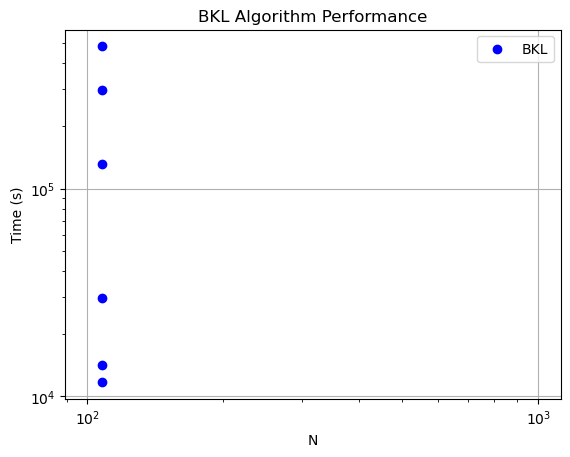

In [44]:
x = [12*9, 12*9, 12*9, 12*9, 12*9, 12*9]
x1 = [12*9, 15*12, 18*15, 21*18, 24*21, 27*24]
y1 = [27187, 36462, 70455, 80239, ]
y = [29600, 28484, 14181, 131877, 297727, 483877]
plt.scatter(x, y, label='BKL', color='blue')
plt.xlabel('N')
plt.ylabel('Time (s)')
plt.xscale('log')
plt.yscale('log')
plt.title('BKL Algorithm Performance')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
5626154/483877

11.627239980408245

In [37]:
1694633.4920124558/297727

5.691903965755393

In [41]:
282544.3852565626/38245

7.3877470324633965

In [45]:
337643.0176307265/33222

10.163235736280974